In [1]:
import pandas
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

In [10]:
f90 = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mosaics/f090_mosaic.fits')
f200 = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mosaics/f200_mosaic.fits')

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval
from reproject import reproject_interp
from scipy.ndimage import gaussian_filter, binary_opening, binary_closing, binary_fill_holes, label

def read_sci_dq(path, sci_ext="SCI", dq_ext="DQ"):
    with fits.open(path) as hdul:
        sci = np.squeeze(hdul[sci_ext].data).astype(float)
        wcs = WCS(hdul[sci_ext].header)
        dq = None
        if dq_ext in hdul:
            dq = np.squeeze(hdul[dq_ext].data)
    sci[~np.isfinite(sci)] = np.nan
    return sci, dq, wcs

def robust_background(img, border=50):
    # quick robust bg estimate from the border pixels
    ny, nx = img.shape
    rim = np.zeros_like(img, dtype=bool)
    rim[:border, :] = True
    rim[-border:, :] = True
    rim[:, :border] = True
    rim[:, -border:] = True
    vals = img[rim & np.isfinite(img)]
    if vals.size == 0:
        return 0.0
    return np.nanmedian(vals)

def mad_std(x):
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - med))

def remove_small_regions(mask, min_pixels=200):
    lab, n = label(mask)
    if n == 0:
        return mask
    counts = np.bincount(lab.ravel())
    keep = np.zeros_like(counts, dtype=bool)
    keep[counts >= min_pixels] = True
    keep[0] = False
    return keep[lab]

def read_sci_dq(path, sci_ext="SCI", dq_ext="DQ"):
    with fits.open(path) as hdul:
        if sci_ext not in hdul:
            sci = hdul[0].data
            wcs = WCS(hdul[0].header)
            dq = None
            return sci, dq, wcs
        sci = np.squeeze(hdul[sci_ext].data).astype(float)
        wcs = WCS(hdul[sci_ext].header)
        dq = None
        if dq_ext in hdul:
            dq = np.squeeze(hdul[dq_ext].data)
    sci[~np.isfinite(sci)] = np.nan
    return sci, dq, wcs

In [11]:
i090 = f90[0].data
w090 = WCS(f90[0].header)
i200 = f200[0].data
w200 = WCS(f200[0].header)

#i090_r, _ = reproject_interp((i090, w090), w200, shape_out=i200.shape)

In [6]:
 # Ratio -> color (dust makes ratio smaller -> color larger)

ratio = (i090_r) / (i200)
dmag = -2.5 * np.log10(ratio)

#dmag_no_nan = np.where(np.isfinite(dmag), dmag, 3)
#mask_new = dmag_no_nan > 1
dmag_no_nan = np.where(np.isfinite(dmag), dmag, 1000)

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_25274/3270799839.py:4: RuntimeWarning: invalid value encountered in log10
  dmag = -2.5 * np.log10(ratio)


In [9]:
# save the dmag to a fits file
hdu_dmag = fits.PrimaryHDU(dmag, header=WCS(f200[0].header).to_header())
hdu_dmag.writeto("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mosaics/f090_f200_dmag.fits", overwrite=True)

In [14]:
hdu_dmag = fits.open("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mosaics/f090_f200_dmag.fits")
dmag = hdu_dmag[0].data
dmag_no_nan = np.where(np.isfinite(dmag), dmag, 0)


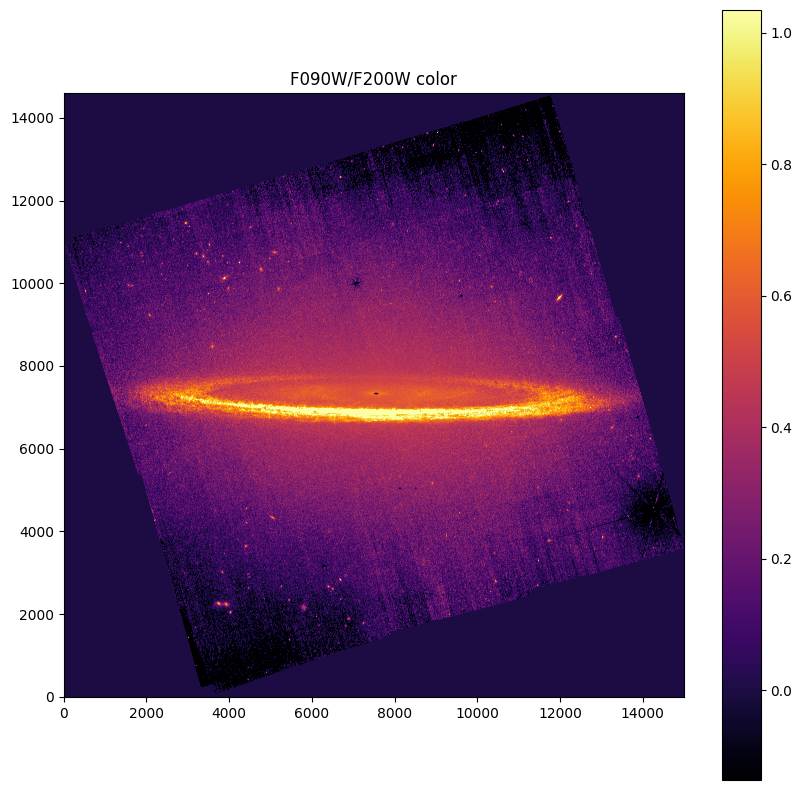

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))
cb = ax.imshow(dmag_no_nan, origin="lower", cmap="inferno",
            vmin=np.nanpercentile(dmag_no_nan, 5), vmax=np.nanpercentile(dmag_no_nan, 99.5))
plt.colorbar(cb, ax=ax)
ax.set_title("F090W/F200W color")
plt.show()


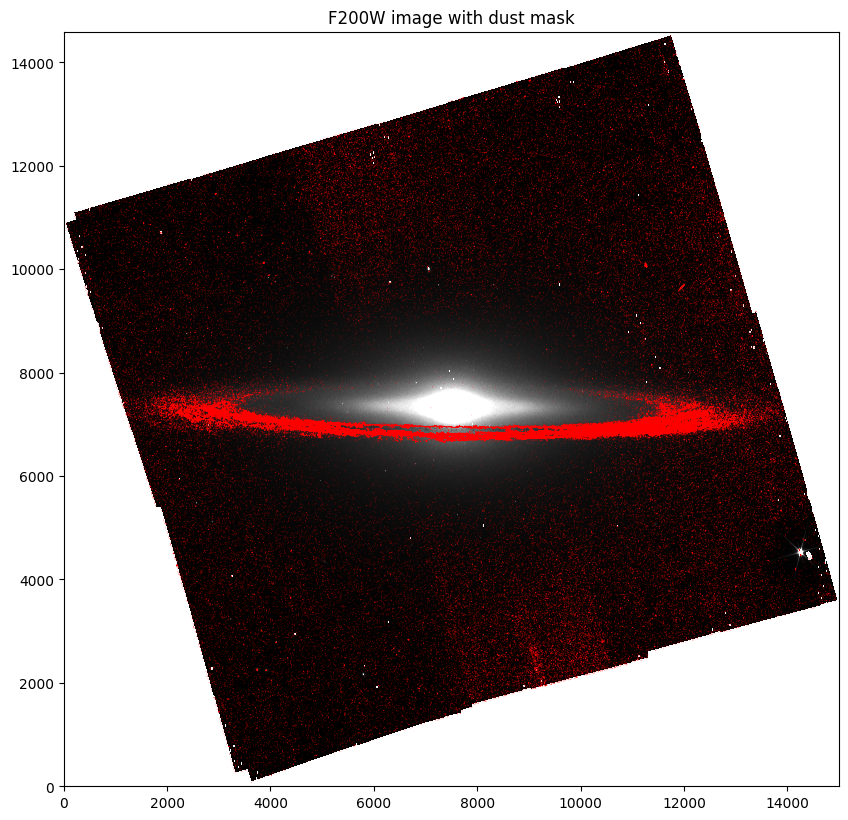

In [12]:
# define threshold for dust mask
dust_mask = dmag_no_nan > 1

# plot the f200 image with the dust mask overlaid
fig, ax = plt.subplots(figsize=(10, 10))
cb = ax.imshow(i200, origin="lower", cmap="gray",
            vmin=np.nanpercentile(i200, 5), vmax=np.nanpercentile(i200, 99.5))
ax.contour(dust_mask, colors="red", linewidths=0.5)
ax.set_title("F200W image with dust mask")
plt.show()

In [13]:
# save the dust mask to a fits file
hdu_mask = fits.PrimaryHDU(dust_mask.astype(int), header=WCS(f200[0].header).to_header())
hdu_mask.writeto("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/f200_mask_1.fits", overwrite=True)